# 01 — Data Loading & Exploratory Data Analysis (BAFU 2219)

Loads BAFU/FOEN discharge data for the Simme at Oberried/Lenk (station 2219) and
builds an **extended Annual Maximum Series (AMS) for 1944–2025** by combining:
- `Tagesmaxima` (daily maxima, 1974–2025) for the full-resolution period
- `Monatsmaxima` (monthly maxima, 1944–2025) for 1944–1973 — the annual block
  maximum equals the maximum of the 12 monthly maxima and is identical to the
  daily-maximum AMS where the two series overlap (verified: max diff = 0.000 m³/s).

The GLOF catalogue is updated with 8 confirmed outburst years (2011–2018, including
2016), with dates derived from the Lac des Faverges lake-level time series
(`data/lake_data/time_vol_YYYY.csv`).  Corrected GLOF_DATES are now in `utils.py`.

Exports `data/processed/annual_summary_2219_extended.csv` (1944–2025, n=82).

| # | Step | Lecture Reference |
|---|------|------------------|
| 1 | Tagesmaxima loading & QC | — |
| 2 | Monatsmaxima & extended AMS | — |
| 3 | GLOF event catalogue | — |
| 3a | Lake-level data: GLOF date extraction | — |
| 4 | Descriptive statistics | Module 1, §1.2 |
| 5 | Time series + annual maxima plot | — |
| 6 | Export processed data | — |

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from utils import (load_2219_discharge, load_monatsmaxima, build_extended_ams,
                   extract_annual_maxima, GLOF_DATES, GLOF_WINDOW)

FIGS     = Path('../figures_2219/01_eda')
DATA_OUT = Path('../data/processed')
FIGS.mkdir(parents=True, exist_ok=True)
DATA_OUT.mkdir(exist_ok=True)

## 1 — Raw Discharge Loading & Quality Control

In [10]:
Q_daily_raw = load_2219_discharge()

# Drop partial year 2026
Q_daily = Q_daily_raw[Q_daily_raw.index.year <= 2025]

print(f'Station:  BAFU/FOEN 2219 — Simme at Oberried/Lenk')
print(f'Series:   Tagesmaxima (daily maximum discharge)')
print(f'Period:   {Q_daily.index[0].date()}  to  {Q_daily.index[-1].date()}')
print(f'Days:     {len(Q_daily):,}  |  NaN: {Q_daily.isna().sum()}')
print(f'Range:    {Q_daily.min():.2f} – {Q_daily.max():.1f} m³/s  |  mean: {Q_daily.mean():.2f} m³/s')
if Q_daily_raw.index.year.max() == 2026:
    n_dropped = (Q_daily_raw.index.year == 2026).sum()
    print(f'\nNote: dropped {n_dropped} records from partial year 2026.')

Station:  BAFU/FOEN 2219 — Simme at Oberried/Lenk
Series:   Tagesmaxima (daily maximum discharge)
Period:   1974-01-01  to  2025-12-31
Days:     18,993  |  NaN: 20
Range:    0.01 – 56.9 m³/s  |  mean: 2.82 m³/s

Note: dropped 136 records from partial year 2026.


## 2 — Monthly Maxima (Monatsmaxima) & Extended AMS

BAFU also provides `Monatsmaxima` back to 1944.  The annual maximum of monthly maxima
equals the annual maximum of daily maxima (verified: zero difference over 1974–2025),
so splicing the two records at 1974 extends the AMS without bias.

In [11]:
mmax = load_monatsmaxima()
print(f'Monatsmaxima: {mmax["year"].min()}–{mmax["year"].max()}  '
      f'({len(mmax)} monthly records, {mmax["year"].nunique()} years)')

# Extended AMS: monthly maxima for 1944-1973, daily maxima for 1974-2025
Q_ext = build_extended_ams(tagesmaxima=Q_daily, monatsmaxima=mmax)
print(f'\nExtended AMS: {Q_ext.index[0]}–{Q_ext.index[-1]},  n={len(Q_ext)}')
print(f'  Pre-GLOF reference (1944–2010): n={len(Q_ext[Q_ext.index < 2011])}')
print(f'  GLOF period (2011–2018):        n={(Q_ext.index >= 2011).sum() - (Q_ext.index > 2018).sum()}')
print(f'  Post-bypass (2019–2025):        n={(Q_ext.index > 2018).sum()}')

# Verify zero gap at splice point
ann_monthly = mmax.groupby('year')['Q_m3s'].max()
ann_daily   = extract_annual_maxima(Q_daily)
overlap_diff = (ann_monthly.loc[1974:2025] - ann_daily).abs().max()
print(f'\nMax difference monthly vs daily AMS (1974–2025): {overlap_diff:.4f} m³/s')

Monatsmaxima: 1944–2025  (984 monthly records, 82 years)

Extended AMS: 1944–2025,  n=82
  Pre-GLOF reference (1944–2010): n=67
  GLOF period (2011–2018):        n=8
  Post-bypass (2019–2025):        n=7

Max difference monthly vs daily AMS (1974–2025): 0.0000 m³/s


## 3 — GLOF Event Catalogue

Eight confirmed outburst years (2011–2018, including 2016).  Dates are derived from the
Lac des Faverges lake-level time series (`data/lake_data/time_vol_YYYY.csv`):
the reported date is the timestamp of **peak lake outflow**.  2011 relies on press and
cantonal archive sources (no lake logger data).  All dates are now stored in
`GLOF_DATES` in `utils.py`.

Key corrections vs. previous version:
- 2012: corrected Jul-24 → **Jul-16** (lake peak)
- 2013: corrected Aug-06 → **Aug-02** (lake peak)
- 2014: minor correction Aug-08 → **Aug-07**
- 2015: minor correction Aug-03 → **Aug-01**
- **2016: newly added** — lake discharge 40.3 m³/s, gauge confirmed same day (Aug-28)

Each event is masked with a ±5-day window in the homogeneity analysis (Notebook 03).

### 3a — Deriving GLOF Dates from the Lac des Faverges Lake-Level Time Series

The lake-level logger at Lac des Faverges records water level (m a.s.l.), inferred lake
volume (m³), and computed discharge (m³/s) at 10-minute resolution.  Data are available
for 2012–2019 (`data/lake_data/time_vol_YYYY.csv`); 2011 has no logger record.

**Extraction logic:**
1. Load each year's CSV and parse the compound timestamp (Year/Month/Day/Hour/Min/Sec).
2. Identify the **outburst phase**: timesteps where the lake volume is decreasing
   (`Δvolume < 0`) and the outflow discharge exceeds a threshold of 5 m³/s.
3. The GLOF peak date is the timestamp of **maximum discharge** during the outburst phase.
4. Compare derived dates to the gauge record (BAFU 2219) to verify propagation delay.

The extracted dates are stored in `GLOF_DATES` in `utils.py` and used throughout the
analysis.  The 2016 event was previously undocumented in the catalogue; the lake data
confirm a 40 m³/s outburst on 28 August 2016.

In [12]:
LAKE_DIR = Path('../data/lake_data')

def load_lake_data(year: int) -> pd.DataFrame | None:
    """Load Lac des Faverges 10-min time series for a given year."""
    fp = LAKE_DIR / f'time_vol_{year}.csv'
    if not fp.exists():
        return None
    df = pd.read_csv(fp, sep=';', header=0)
    df['timestamp'] = pd.to_datetime({
        'year': df['Year'], 'month': df['Month'], 'day': df['Day'],
        'hour': df['Hour'], 'minute': df['Min'], 'second': df['Sec'],
    })
    df = (df.rename(columns={'level(m)': 'level_m',
                              'volume(m3)': 'volume_m3',
                              'discharge(m3/s)': 'discharge_m3s'})
            .set_index('timestamp')
            .sort_index()[['level_m', 'volume_m3', 'discharge_m3s']])
    return df


def extract_glof_peak(df: pd.DataFrame, min_discharge: float = 5.0):
    """
    Identify the GLOF outburst phase and return peak discharge timestamp + value.

    Outburst phase: volume is decreasing (delta_V < 0) AND discharge > min_discharge.
    Peak = timestamp of maximum discharge within that phase.
    """
    vol_diff = df['volume_m3'].diff()
    outburst = df[(vol_diff < 0) & (df['discharge_m3s'] > min_discharge)]
    if outburst.empty:
        return None, float('nan')
    peak_ts  = outburst['discharge_m3s'].idxmax()
    peak_val = outburst['discharge_m3s'].max()
    return peak_ts, peak_val


# --- Extract for each year with lake data and compare to GLOF_DATES ---
print(f'{"Year":>5}  {"Extracted peak date":>22}  {"Q_lake (m3/s)":>14}  '
      f'{"In GLOF_DATES":>22}  {"Lag":>8}')
print('-' * 82)

lake_results = {}
for year in range(2012, 2020):
    df = load_lake_data(year)
    if df is None:
        continue
    peak_ts, peak_q = extract_glof_peak(df)
    lake_results[year] = (df, peak_ts, peak_q)

    stored_dt = GLOF_DATES.get(year)
    if stored_dt is None:
        stored_str = 'not in catalogue'
        lag_str = '—'
    else:
        stored_str = str(stored_dt.date())
        if peak_ts is not None:
            lag = (stored_dt - peak_ts).total_seconds() / 3600
            lag_str = f'{lag:+.1f} h'
        else:
            lag_str = '—'

    peak_str = str(peak_ts.date()) if peak_ts is not None else 'not found'
    print(f'{year:>5}  {peak_str:>22}  {peak_q:>14.2f}  {stored_str:>22}  {lag_str:>8}')

print()
print('Note: 2011 has no lake logger data — date from cantonal archive / press sources.')
print('      2019 (bypass channel) is shown for completeness; no free outburst expected.')

 Year     Extracted peak date   Q_lake (m3/s)           In GLOF_DATES       Lag
----------------------------------------------------------------------------------
 2012              2012-07-16           11.25              2012-07-16   -12.2 h
 2013              2013-08-02           16.59              2013-08-02    -4.7 h
 2014              2014-08-07           18.36              2014-08-07    -4.5 h
 2015              2015-08-01            6.79              2015-08-01   -18.2 h
 2016              2016-08-28           40.35              2016-08-28    -0.8 h
 2017              2017-07-19           32.16              2017-07-19   -19.7 h
 2018              2018-07-27           83.18              2018-07-27   -13.3 h
 2019               not found             nan        not in catalogue         —

Note: 2011 has no lake logger data — date from cantonal archive / press sources.
      2019 (bypass channel) is shown for completeness; no free outburst expected.


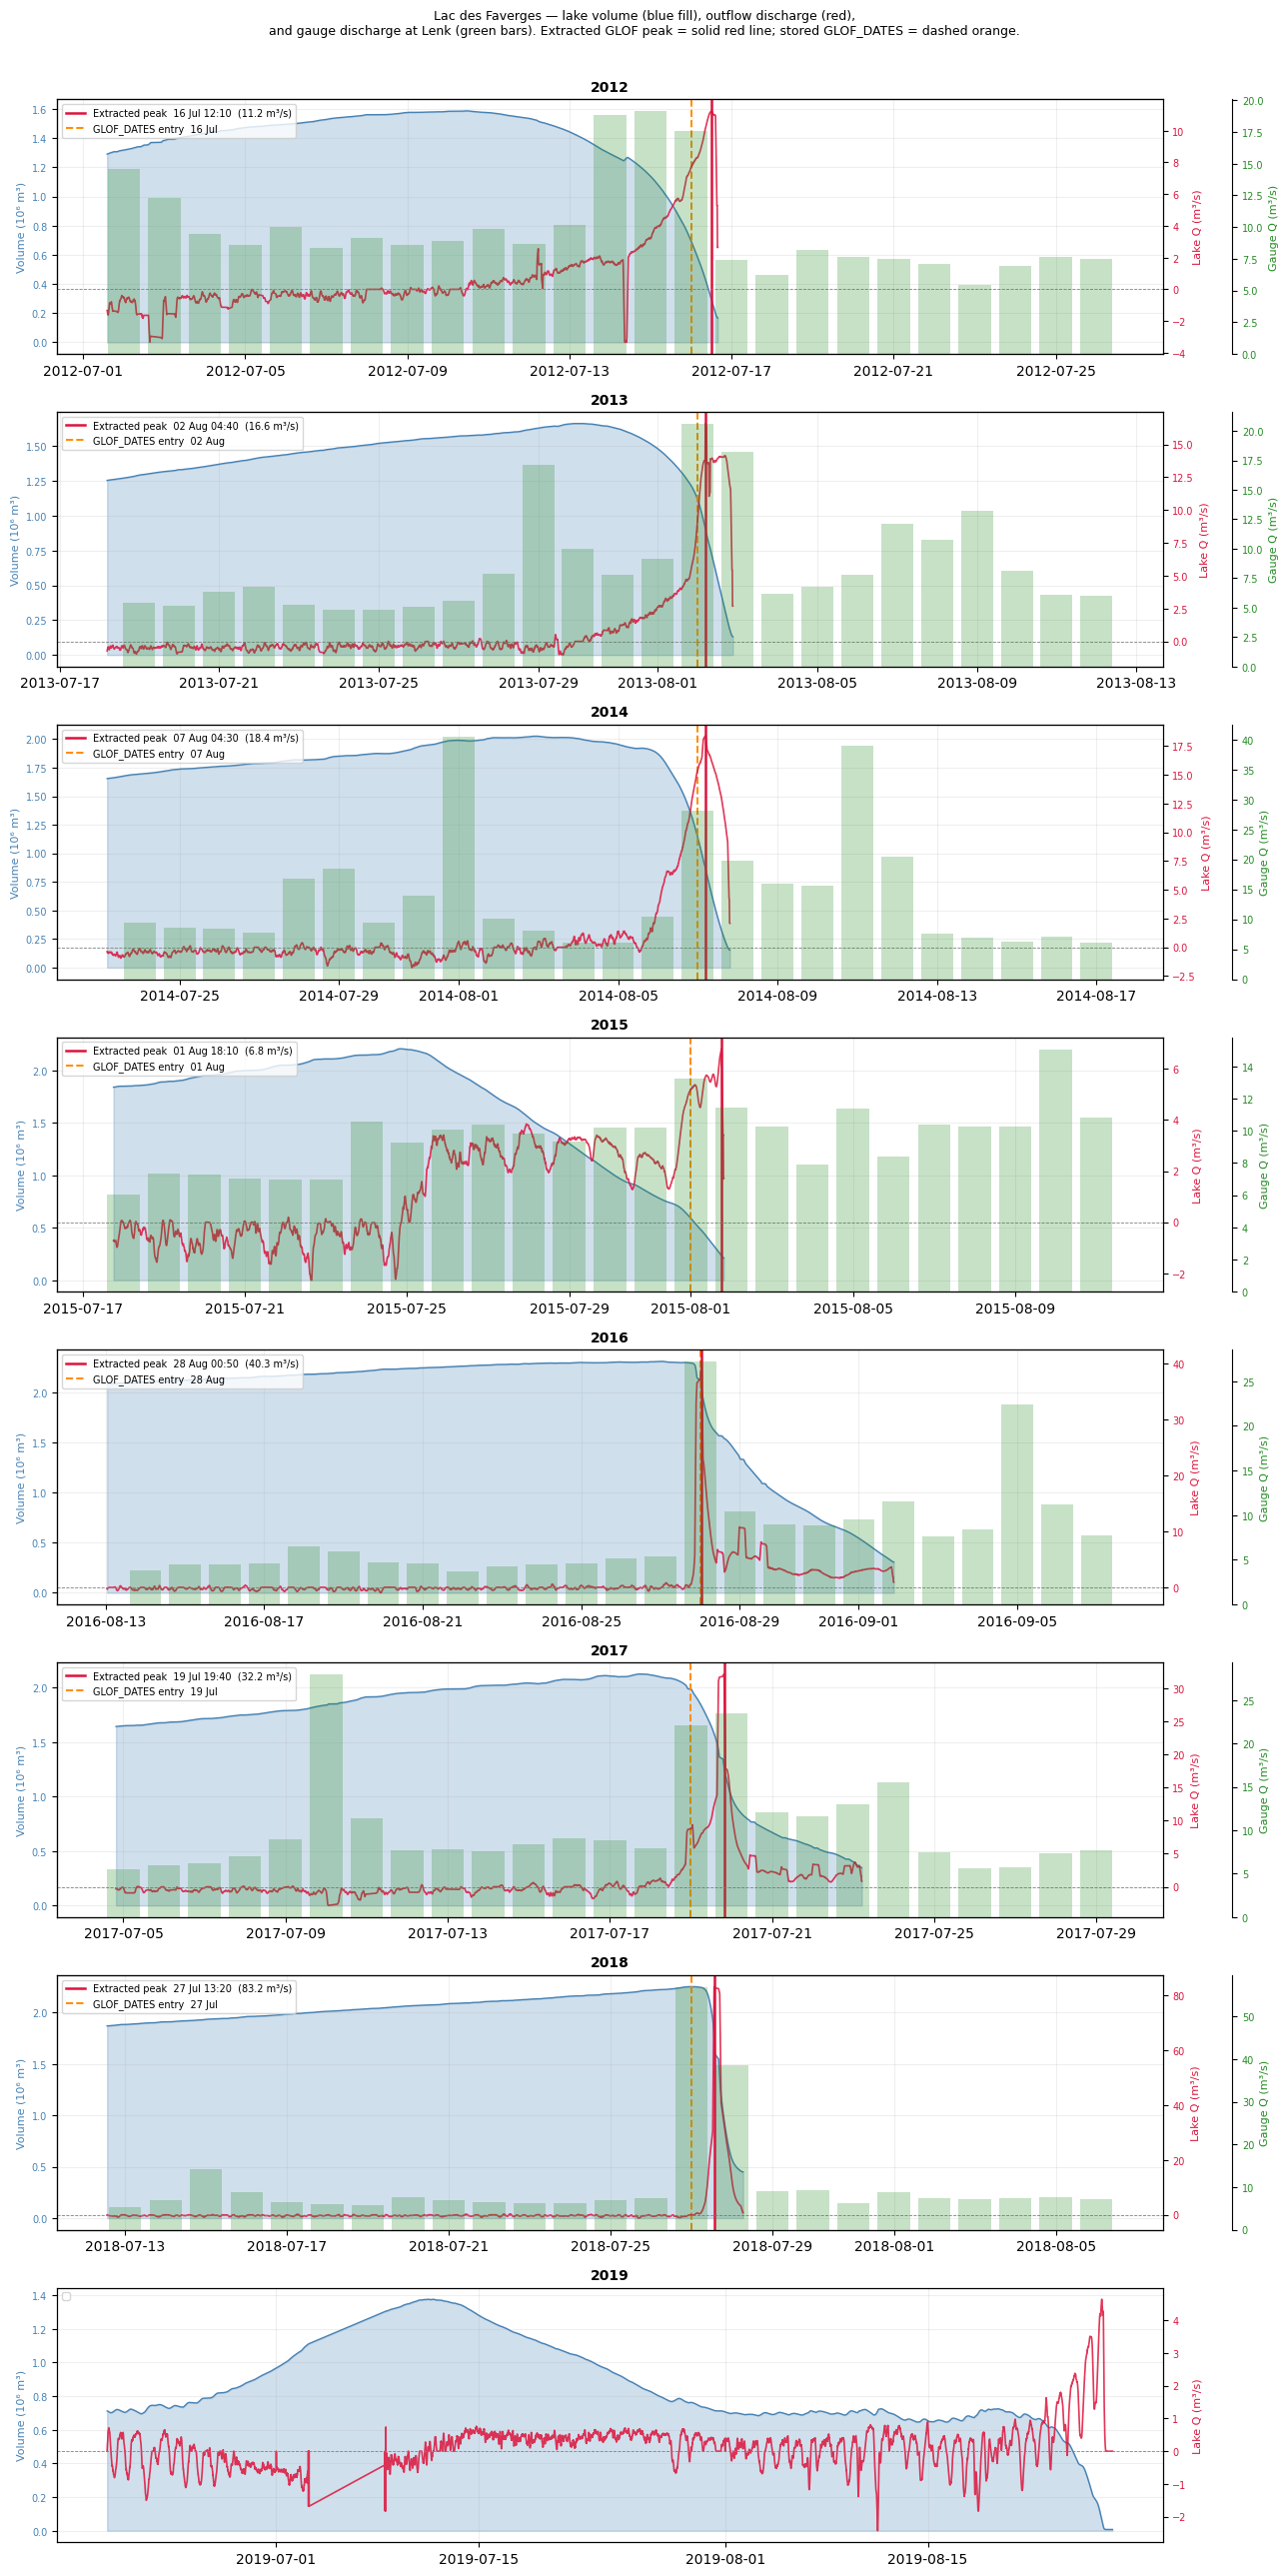

Saved -> figures_2219/01_eda/01b_lake_glof_dates.png


In [13]:
# Visualise lake volume + discharge for each year with data, zoomed to the outburst window

years_with_data = [yr for yr in range(2012, 2020) if yr in lake_results]
n_years = len(years_with_data)
fig, axes = plt.subplots(n_years, 1, figsize=(13, 3.2 * n_years), sharex=False)

for ax, year in zip(axes, years_with_data):
    df, peak_ts, peak_q = lake_results[year]

    # Zoom: ±15 days around peak
    if peak_ts is not None:
        t0 = peak_ts - pd.Timedelta(days=15)
        t1 = peak_ts + pd.Timedelta(days=10)
        sub = df.loc[t0:t1]
    else:
        sub = df

    # Lake volume on left axis
    color_vol = 'steelblue'
    ax.fill_between(sub.index, sub['volume_m3'] / 1e6, alpha=0.25, color=color_vol)
    ax.plot(sub.index, sub['volume_m3'] / 1e6, color=color_vol, lw=1.0)
    ax.set_ylabel('Volume (10⁶ m³)', color=color_vol, fontsize=8)
    ax.tick_params(axis='y', labelcolor=color_vol, labelsize=7)

    # Lake discharge on right axis
    ax2 = ax.twinx()
    color_dis = 'crimson'
    ax2.plot(sub.index, sub['discharge_m3s'], color=color_dis, lw=1.2, alpha=0.85)
    ax2.axhline(0, color='gray', lw=0.6, ls='--')
    ax2.set_ylabel('Lake Q (m³/s)', color=color_dis, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=color_dis, labelsize=7)

    # Mark extracted GLOF peak and stored GLOF_DATES entry
    if peak_ts is not None:
        ax.axvline(peak_ts, color=color_dis, lw=1.8, ls='-', zorder=5,
                   label=f'Extracted peak  {peak_ts.strftime("%d %b %H:%M")}  ({peak_q:.1f} m³/s)')
    stored_dt = GLOF_DATES.get(year)
    if stored_dt is not None:
        ax.axvline(stored_dt, color='darkorange', lw=1.4, ls='--', zorder=4,
                   label=f'GLOF_DATES entry  {stored_dt.strftime("%d %b")}')

    # Gauge discharge (BAFU 2219) as bar chart in background
    if peak_ts is not None:
        gauge_sub = Q_daily.loc[t0:t1]
        ax3 = ax.twinx()
        ax3.spines['right'].set_position(('outward', 50))
        ax3.bar(gauge_sub.index, gauge_sub.values, color='forestgreen',
                alpha=0.25, width=0.8, label='Gauge Q (BAFU 2219)')
        ax3.set_ylabel('Gauge Q (m³/s)', color='forestgreen', fontsize=8)
        ax3.tick_params(axis='y', labelcolor='forestgreen', labelsize=7)

    ax.set_title(f'{year}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.2)

    # Combined legend
    lines_a, labs_a = ax.get_legend_handles_labels()
    ax.legend(lines_a, labs_a, loc='upper left', fontsize=7)

plt.suptitle(
    'Lac des Faverges — lake volume (blue fill), outflow discharge (red),\n'
    'and gauge discharge at Lenk (green bars). Extracted GLOF peak = solid red line; '
    'stored GLOF_DATES = dashed orange.',
    fontsize=9, y=1.005,
)
plt.tight_layout()
fig.savefig(FIGS / '01b_lake_glof_dates.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> figures_2219/01_eda/01b_lake_glof_dates.png')

In [14]:
print(f'GLOF events documented ({len(GLOF_DATES)} years, ±{GLOF_WINDOW}-day window):')
for yr, dt in GLOF_DATES.items():
    q_on_date = Q_daily.get(dt, float('nan'))
    print(f'  {yr}: {dt.date()}   Q on GLOF day = {q_on_date:.2f} m³/s')

GLOF events documented (8 years, ±5-day window):
  2011: 2011-07-27   Q on GLOF day = 3.26 m³/s
  2012: 2012-07-16   Q on GLOF day = 17.55 m³/s
  2013: 2013-08-02   Q on GLOF day = 20.59 m³/s
  2014: 2014-08-07   Q on GLOF day = 28.11 m³/s
  2015: 2015-08-01   Q on GLOF day = 13.23 m³/s
  2016: 2016-08-28   Q on GLOF day = 27.16 m³/s
  2017: 2017-07-19   Q on GLOF day = 22.13 m³/s
  2018: 2018-07-27   Q on GLOF day = 56.90 m³/s


## 4 — Descriptive Statistics (Module 1, §1.2)

Uses the extended AMS (1944–2025, n=82).  GLOF years are 2011–2018 (8 years).

In [15]:
glof_years = set(GLOF_DATES.keys())

# Use extended AMS for the annual summary DataFrame
Q_ann_date = Q_daily.resample('YE').apply(lambda s: s.idxmax())
Q_ann_date.index = Q_ann_date.index.year

annual = pd.DataFrame({
    'Q_max':      Q_ext,
    'Q_max_date': Q_ann_date.reindex(Q_ext.index),  # NaN for 1944-1973 (no daily data)
    'is_glof':    [yr in glof_years for yr in Q_ext.index],
})
annual.index.name = 'year'

print(f'Extended Annual Maximum Series: n={len(annual)} years  ({annual.index[0]}–{annual.index[-1]})')
print(f'GLOF years in AMS: {sorted(glof_years & set(annual.index))}')
print(f'\nGLOF event dates and gauge discharge on outburst day:')
for yr, dt in GLOF_DATES.items():
    q_on_date = Q_daily.get(dt, float('nan'))
    print(f'  {yr}: {dt.date()}   Q on GLOF day = {q_on_date:.2f} m³/s')

Extended Annual Maximum Series: n=82 years  (1944–2025)
GLOF years in AMS: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]

GLOF event dates and gauge discharge on outburst day:
  2011: 2011-07-27   Q on GLOF day = 3.26 m³/s
  2012: 2012-07-16   Q on GLOF day = 17.55 m³/s
  2013: 2013-08-02   Q on GLOF day = 20.59 m³/s
  2014: 2014-08-07   Q on GLOF day = 28.11 m³/s
  2015: 2015-08-01   Q on GLOF day = 13.23 m³/s
  2016: 2016-08-28   Q on GLOF day = 27.16 m³/s
  2017: 2017-07-19   Q on GLOF day = 22.13 m³/s
  2018: 2018-07-27   Q on GLOF day = 56.90 m³/s


## 4 — Descriptive Statistics (Module 1, §1.2)

In [16]:
Q = annual['Q_max']
Q_no_glof = Q[~annual['is_glof']]
Q_glof    = Q[ annual['is_glof']]

print(f'                   Full series   Non-GLOF years   GLOF years (2011-2018)')
print(f'n                  {len(Q):>11}   {len(Q_no_glof):>14}   {len(Q_glof):>10}')
print(f'Mean (m³/s)        {Q.mean():>11.2f}   {Q_no_glof.mean():>14.2f}   {Q_glof.mean():>10.2f}')
print(f'Std  (m³/s)        {Q.std():>11.2f}   {Q_no_glof.std():>14.2f}   {Q_glof.std():>10.2f}')
print(f'Median (m³/s)      {Q.median():>11.2f}   {Q_no_glof.median():>14.2f}   {Q_glof.median():>10.2f}')
print(f'Min / Max (m³/s)   {Q.min():.2f} / {Q.max():.2f}   {Q_no_glof.min():.2f} / {Q_no_glof.max():.2f}   {Q_glof.min():.2f} / {Q_glof.max():.2f}')

print('\nTop 10 annual maxima (extended AMS):')
top10 = annual['Q_max'].nlargest(10).to_frame().join(annual[['Q_max_date', 'is_glof']])
print(top10.to_string())

                   Full series   Non-GLOF years   GLOF years (2011-2018)
n                           82               74            8
Mean (m³/s)              18.46            17.28        29.35
Std  (m³/s)               7.51             5.55        13.45
Median (m³/s)            16.41            16.09        27.13
Min / Max (m³/s)   9.89 / 56.90   9.89 / 34.67   15.55 / 56.90

Top 10 annual maxima (extended AMS):
       Q_max Q_max_date  is_glof
year                            
2018  56.901 2018-07-27     True
2014  40.475 2014-08-01     True
1982  34.672 1982-07-24    False
1989  33.687 1989-07-24    False
1992  32.353 1992-08-07    False
2009  29.791 2009-07-17    False
1986  29.610 1986-07-06    False
1998  28.064 1998-08-23    False
2020  27.980 2020-07-30    False
2017  27.950 2017-07-10     True


## 5 — Time Series & Annual Maxima Plot

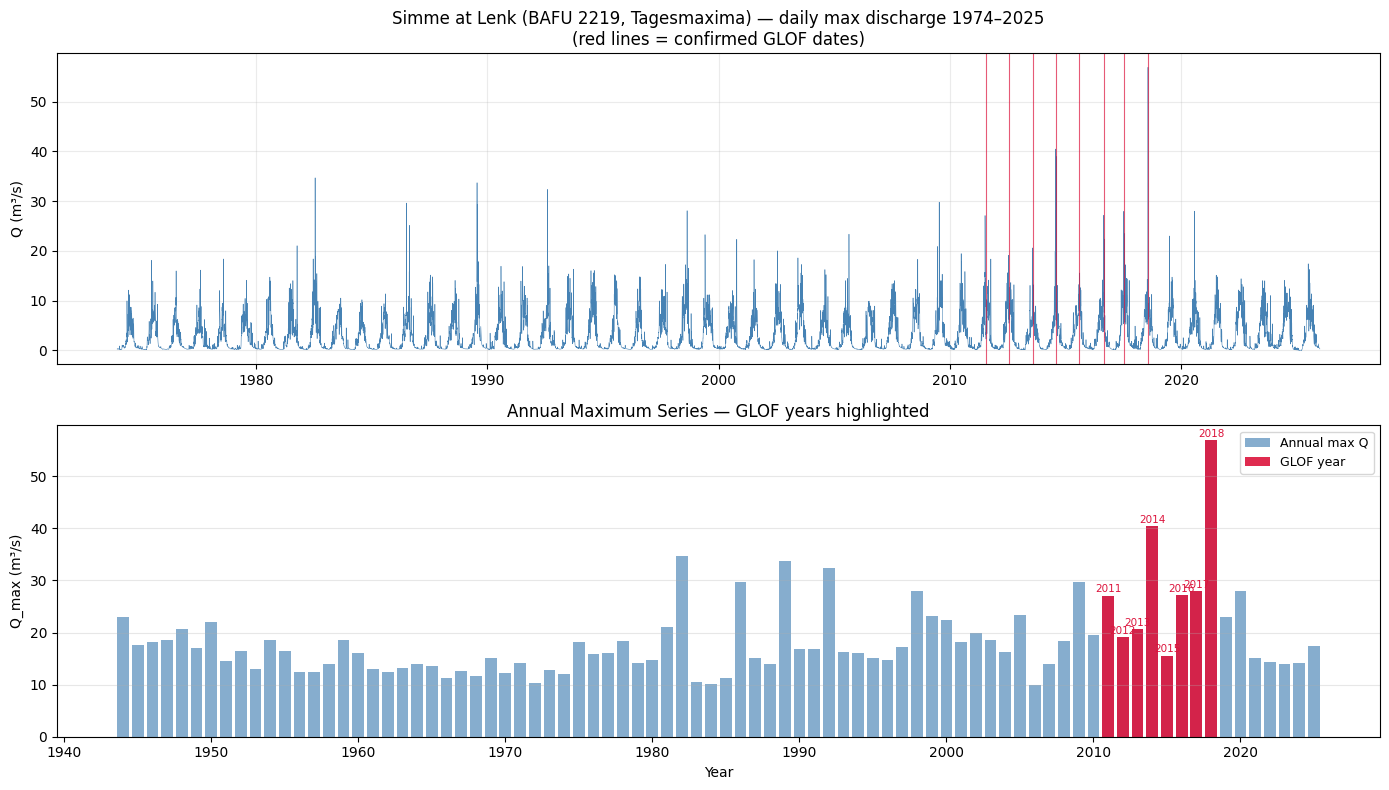

Saved -> figures_2219/01_eda/01_discharge_overview.png


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Panel A: daily discharge
ax = axes[0]
ax.plot(Q_daily.index, Q_daily.values, lw=0.4, color='steelblue')
for dt in GLOF_DATES.values():
    ax.axvline(dt, color='crimson', lw=0.8, alpha=0.7)
ax.set_ylabel('Q (m³/s)')
ax.set_title('Simme at Lenk (BAFU 2219, Tagesmaxima) — daily max discharge 1974–2025\n(red lines = confirmed GLOF dates)')
ax.grid(alpha=0.25)

# Panel B: annual maxima bar chart
ax2 = axes[1]
glof_mask = annual['is_glof']
ax2.bar(annual.index, annual['Q_max'], color='steelblue', alpha=0.65, label='Annual max Q')
ax2.bar(
    annual.index[glof_mask], annual.loc[glof_mask, 'Q_max'],
    color='crimson', alpha=0.9, label='GLOF year'
)
for yr in annual.index[glof_mask]:
    ax2.text(yr, annual.loc[yr, 'Q_max'] + 0.25, str(yr),
             ha='center', va='bottom', fontsize=7.5, color='crimson')
ax2.set_xlabel('Year')
ax2.set_ylabel('Q_max (m³/s)')
ax2.set_title('Annual Maximum Series — GLOF years highlighted')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGS / '01_discharge_overview.png', dpi=150)
plt.show()
print('Saved -> figures_2219/01_eda/01_discharge_overview.png')

## 6 — Export Processed Data

In [18]:
annual.to_csv(DATA_OUT / 'annual_summary_2219_extended.csv')
print(f'Saved -> data/processed/annual_summary_2219_extended.csv  ({len(annual)} rows, 1944-2025)')

Saved -> data/processed/annual_summary_2219_extended.csv  (82 rows, 1944-2025)
